In [75]:
import subprocess
import os
import sys
import matplotlib.pyplot as plt
import pandas
import numpy as np
import subprocess

In [76]:
commande = ["make", "run", 'ARGS=net3_1s.inp output_epanet.txt output_algo.txt 0.5 1.0']
resultat = subprocess.run(commande, capture_output=True, text=True)

print(resultat.stdout)
print(resultat.stderr)

./epanet_exec net3_1s.inp output_epanet.txt output_algo.txt 0.5 1.0




In [77]:
def parser(path):
    with open(path, 'r') as f:
        n = int(f.readline().strip())
        arcs = int(f.readline().strip())
        efficacite = float(f.readline().strip())
        sym_arcs = int(f.readline().strip())
        return  (np.loadtxt(f).reshape(n, n), arcs, n, efficacite, sym_arcs)

parser('output_epanet.txt')

(array([[    0.    ,     0.    ,     0.    , ...,     0.    ,     0.    ,
             0.    ],
        [    0.    ,     0.    ,     0.    , ...,     0.    ,     0.    ,
             0.    ],
        [    0.    ,     0.    ,     0.    , ...,     0.    ,     0.    ,
             0.    ],
        ...,
        [    0.    ,     0.    ,     0.    , ...,     0.    ,   437.6261,
             0.    ],
        [    0.    ,     0.    ,     0.    , ...,     0.    ,     0.    ,
             0.    ],
        [    0.    ,     0.    , 40751.4816, ...,     0.    ,     0.    ,
             0.    ]], shape=(87, 87)),
 107,
 87,
 0.9831,
 0)

In [78]:
def hamming_distance_non_symmetrique(m1, m2):
    return np.sum((m1 != 0) != (m2 != 0))


def hamming_distance_symmetrique(m1, m2):
    mask = np.triu(np.ones(m1.shape, dtype=bool), k=1)
    return np.sum(((m1 != 0) != (m2 != 0))[mask])

result, arcs, n, efficacite, sym_arcs = parser('output_epanet.txt')
print("EPANET comparaison:\n" + "nbr arcs=" + str(arcs) + "\n" + "nbr noeuds=" + str(n) + "\n" + "efficacite=" + str(efficacite) + "\n" + "sym_arcs=" + str(sym_arcs))
result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo = parser('output_algo.txt')
print("ALGO comparaison:\n" + "nbr arcs=" + str(arcs_algo) + "\n" + "nbr noeuds=" + str(n_algo) + "\n" + "efficacite=" + str(efficacite_algo) + "\n" + "sym_arcs=" + str(sym_arcs_algo))

print(hamming_distance_non_symmetrique(result, result_algo))
print(hamming_distance_symmetrique(result, result_algo))

EPANET comparaison:
nbr arcs=107
nbr noeuds=87
efficacite=0.9831
sym_arcs=0
ALGO comparaison:
nbr arcs=33
nbr noeuds=87
efficacite=0.2579
sym_arcs=0
84
47


# COMPARAISON Hamming

## demande fixe avec multiplicateur source somme ponderé

In [79]:
multipliers_source = np.linspace(0.0001, 10.0, 1000)
multipliers_destination = np.linspace(1.0, 1.0, 1)

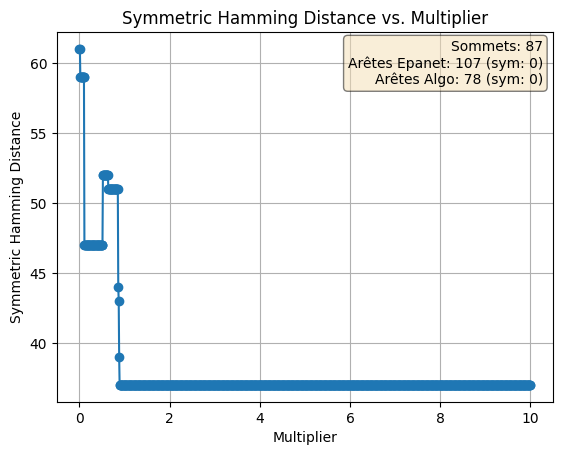

In [80]:
distances = []

for mult_source in multipliers_source:
	for mult_destination in multipliers_destination:
		commande = ["make", "run", f'ARGS=net3_1s.inp output_epanet.txt output_algo.txt {mult_source} {mult_destination}']
		resultat = subprocess.run(commande, capture_output=True, text=True)

		result, arcs, n, efficacite, sym_arcs = parser('output_epanet.txt')
		result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo = parser('output_algo.txt')

		dist = hamming_distance_symmetrique(result, result_algo)
		distances.append(dist)

fig, ax = plt.subplots()
ax.plot(multipliers, distances, marker='o')
ax.set_xlabel('Multiplier')
ax.set_ylabel('Symmetric Hamming Distance')
ax.set_title('Symmetric Hamming Distance vs. Multiplier')
ax.grid(True)

# Add number of nodes and arcs at top right
ax.text(0.98, 0.98, f'Sommets: {n}\nArêtes Epanet: {arcs} (sym: {sym_arcs})\nArêtes Algo: {arcs_algo} (sym: {sym_arcs_algo})', 
        transform=ax.transAxes, 
        fontsize=10, 
        verticalalignment='top', 
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

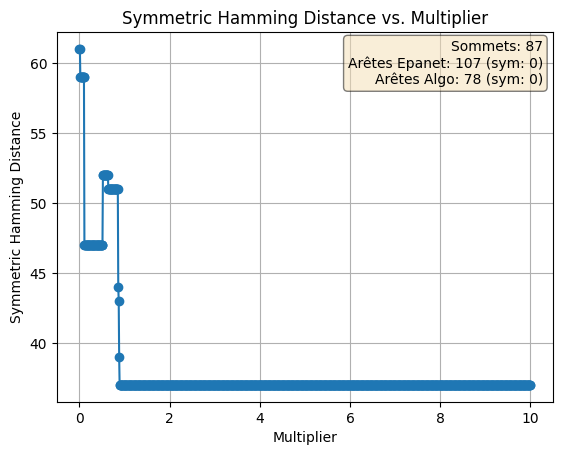

In [81]:
distances = []

for mult_source in multipliers_source:
	for mult_destination in multipliers_destination:
		commande = ["make", "run", f'ARGS=net3_1s.inp output_epanet.txt output_algo.txt {mult_source} {mult_destination}']
		resultat = subprocess.run(commande, capture_output=True, text=True)

		result, arcs, n, efficacite, sym_arcs = parser('output_epanet.txt')
		result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo = parser('output_algo.txt')

		dist = hamming_distance_symmetrique(result, result_algo)
		distances.append(dist)

fig, ax = plt.subplots()
ax.plot(multipliers, distances, marker='o')
ax.set_xlabel('Multiplier')
ax.set_ylabel('Symmetric Hamming Distance')
ax.set_title('Symmetric Hamming Distance vs. Multiplier')
ax.grid(True)

# Add number of nodes and arcs at top right
ax.text(0.98, 0.98, f'Sommets: {n}\nArêtes Epanet: {arcs} (sym: {sym_arcs})\nArêtes Algo: {arcs_algo} (sym: {sym_arcs_algo})', 
        transform=ax.transAxes, 
        fontsize=10, 
        verticalalignment='top', 
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

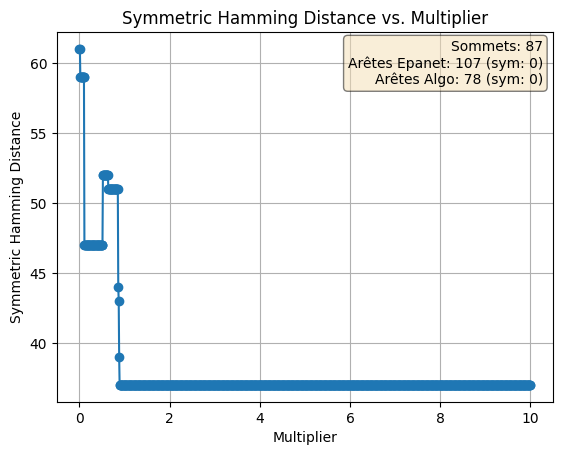

In [82]:
distances = []

for mult_source in multipliers_source:
	for mult_destination in multipliers_destination:
		commande = ["make", "run", f'ARGS=net3_1s.inp output_epanet.txt output_algo.txt {mult_source} {mult_destination}']
		resultat = subprocess.run(commande, capture_output=True, text=True)

		result, arcs, n, efficacite, sym_arcs = parser('output_epanet.txt')
		result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo = parser('output_algo.txt')

		dist = hamming_distance_symmetrique(result, result_algo)
		distances.append(dist)

fig, ax = plt.subplots()
ax.plot(multipliers, distances, marker='o')
ax.set_xlabel('Multiplier')
ax.set_ylabel('Symmetric Hamming Distance')
ax.set_title('Symmetric Hamming Distance vs. Multiplier')
ax.grid(True)

# Add number of nodes and arcs at top right
ax.text(0.98, 0.98, f'Sommets: {n}\nArêtes Epanet: {arcs} (sym: {sym_arcs})\nArêtes Algo: {arcs_algo} (sym: {sym_arcs_algo})', 
        transform=ax.transAxes, 
        fontsize=10, 
        verticalalignment='top', 
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

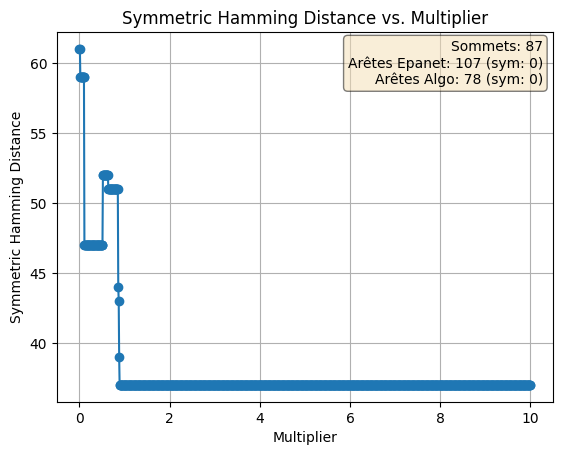

In [83]:
distances = []

for mult_source in multipliers_source:
	for mult_destination in multipliers_destination:
		commande = ["make", "run", f'ARGS=net3_1s.inp output_epanet.txt output_algo.txt {mult_source} {mult_destination}']
		resultat = subprocess.run(commande, capture_output=True, text=True)

		result, arcs, n, efficacite, sym_arcs = parser('output_epanet.txt')
		result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo = parser('output_algo.txt')

		dist = hamming_distance_symmetrique(result, result_algo)
		distances.append(dist)

fig, ax = plt.subplots()
ax.plot(multipliers, distances, marker='o')
ax.set_xlabel('Multiplier')
ax.set_ylabel('Symmetric Hamming Distance')
ax.set_title('Symmetric Hamming Distance vs. Multiplier')
ax.grid(True)

# Add number of nodes and arcs at top right
ax.text(0.98, 0.98, f'Sommets: {n}\nArêtes Epanet: {arcs} (sym: {sym_arcs})\nArêtes Algo: {arcs_algo} (sym: {sym_arcs_algo})', 
        transform=ax.transAxes, 
        fontsize=10, 
        verticalalignment='top', 
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

# Efficacite EPA vs Efficacite FF